#Financial Ratios & Exploratory Data Analysis

This notebook connects to the SQLite database built in Step 2 (`sql/french_equities.db`),
computes standard financial ratios for each company-year, and explores trends and
comparisons across the ~50 CAC 40 / SBF 120 companies.

**Sections:**
1. Setup & load data from SQL
2. Compute financial ratios
3. Save processed data
4. Exploratory analysis & visualizations
5. Key findings


## 1. Setup & load data from SQL

In [12]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DB_PATH = "D:/CV and Certificate/Project/sql/french_equities.db"
conn = sqlite3.connect(DB_PATH)

companies = pd.read_sql("SELECT * FROM companies", conn)
income = pd.read_sql("SELECT * FROM income_statement", conn)
balance = pd.read_sql("SELECT * FROM balance_sheet", conn)
cashflow = pd.read_sql("SELECT * FROM cash_flow", conn)

for df in (income, balance, cashflow):
    df["fiscal_year_end"] = pd.to_datetime(df["fiscal_year_end"])
    df["fiscal_year"] = df["fiscal_year_end"].dt.year

print(f"companies: {companies.shape}")
print(f"income_statement: {income.shape}")
print(f"balance_sheet: {balance.shape}")
print(f"cash_flow: {cashflow.shape}")


companies: (51, 7)
income_statement: (199, 16)
balance_sheet: (199, 17)
cash_flow: (199, 13)


In [13]:
# Merge the 3 statements on ticker + fiscal_year_end into one wide table per company-year
df = (
    income
    .merge(balance, on=["ticker", "fiscal_year_end", "fiscal_year"], how="inner", suffixes=("", "_bs"))
    .merge(cashflow, on=["ticker", "fiscal_year_end", "fiscal_year"], how="inner", suffixes=("", "_cf"))
    .merge(companies, on="ticker", how="left")
)

print(f"Merged company-year rows: {df.shape[0]}")
print(f"Unique companies in merged data: {df['ticker'].nunique()} (out of {companies['ticker'].nunique()} total)")

missing_companies = set(companies["ticker"]) - set(df["ticker"])
if missing_companies:
    print(f"Companies with no matching financial data (excluded): {missing_companies}")

df.sort_values(["ticker", "fiscal_year_end"], inplace=True)
df.head()


Merged company-year rows: 199
Unique companies in merged data: 50 (out of 51 total)
Companies with no matching financial data (excluded): {'URW.AS'}


,ticker,fiscal_year_end,total_revenue,cost_of_revenue,gross_profit,operating_income,operating_expense,ebitda,ebit,pretax_income,...,depreciation_and_amortization,change_in_working_capital,end_cash_position,beginning_cash_position,company_name,sector,industry,country,currency,market_cap
3,AC.PA,2022-12-31,"4,224,000,000.00","2,179,000,000.00","2,045,000,000.00","447,000,000.00","1,598,000,000.00","794,000,000.00","566,000,000.00","460,000,000.00",...,NaN,"57,000,000.00","1,625,000,000.00","1,658,000,000.00",Accor,Consumer Cyclical,Lodging,France,EUR,"10,488,189,952.00"
2,AC.PA,2023-12-31,"5,056,000,000.00","2,502,000,000.00","2,554,000,000.00","724,000,000.00","1,830,000,000.00","1,085,000,000.00","806,000,000.00","679,000,000.00",...,"279,000,000.00","-17,000,000.00","1,279,000,000.00","1,625,000,000.00",Accor,Consumer Cyclical,Lodging,France,EUR,"10,488,189,952.00"
1,AC.PA,2024-12-31,"5,606,000,000.00","2,717,000,000.00","2,889,000,000.00","779,000,000.00","2,110,000,000.00","1,332,000,000.00","991,000,000.00","850,000,000.00",...,"341,000,000.00","-79,000,000.00","1,236,000,000.00","1,279,000,000.00",Accor,Consumer Cyclical,Lodging,France,EUR,"10,488,189,952.00"
0,AC.PA,2025-12-31,"5,639,000,000.00","2,699,000,000.00","2,940,000,000.00","869,000,000.00","2,071,000,000.00","1,139,000,000.00","809,000,000.00","651,000,000.00",...,"330,000,000.00","-111,000,000.00","1,183,000,000.00","1,236,000,000.00",Accor,Consumer Cyclical,Lodging,France,EUR,"10,488,189,952.00"
43,ACA.PA,2022-12-31,"20,646,000,000.00",NaN,NaN,NaN,"13,260,000,000.00",NaN,NaN,"7,871,000,000.00",...,"1,104,000,000.00","-1,878,000,000.00","155,431,000,000.00","159,678,000,000.00",Credit Agricole,Financial Services,Banks - Regional,France,EUR,"56,024,236,032.00"


## 2. Compute financial ratios

Standard profitability, leverage, liquidity, and cash-flow ratios, plus year-over-year
revenue growth (computed per company, since fiscal year-end dates differ slightly
across companies).

In [14]:
# --- Profitability ratios ---
df["gross_margin"] = df["gross_profit"] / df["total_revenue"]
df["operating_margin"] = df["operating_income"] / df["total_revenue"]
df["net_margin"] = df["net_income"] / df["total_revenue"]
df["ebitda_margin"] = df["ebitda"] / df["total_revenue"]

# --- Return ratios ---
df["roe"] = df["net_income"] / df["stockholders_equity"]
df["roa"] = df["net_income"] / df["total_assets"]

# --- Leverage / solvency ratios ---
df["debt_to_equity"] = df["total_debt"] / df["stockholders_equity"]
df["net_debt_to_ebitda"] = df["net_debt"] / df["ebitda"]

# --- Liquidity ratios ---
df["current_ratio"] = df["current_assets"] / df["current_liabilities"]

# --- Cash flow ratios ---
df["fcf_margin"] = df["free_cash_flow"] / df["total_revenue"]
df["capex_to_revenue"] = df["capital_expenditure"].abs() / df["total_revenue"]

# --- Year-over-year growth (per company, based on prior row after sorting) ---
df["revenue_growth_yoy"] = df.groupby("ticker")["total_revenue"].pct_change()
df["net_income_growth_yoy"] = df.groupby("ticker")["net_income"].pct_change()

ratio_cols = [
    "gross_margin", "operating_margin", "net_margin", "ebitda_margin",
    "roe", "roa", "debt_to_equity", "net_debt_to_ebitda", "current_ratio",
    "fcf_margin", "capex_to_revenue", "revenue_growth_yoy", "net_income_growth_yoy",
]

# Replace inf (from division by zero / negative equity) with NaN for cleanliness
df[ratio_cols] = df[ratio_cols].replace([np.inf, -np.inf], np.nan)

df[["ticker", "company_name", "fiscal_year"] + ratio_cols].head(10)


,ticker,company_name,fiscal_year,gross_margin,operating_margin,net_margin,ebitda_margin,roe,roa,debt_to_equity,net_debt_to_ebitda,current_ratio,fcf_margin,capex_to_revenue,revenue_growth_yoy,net_income_growth_yoy
3,AC.PA,Accor,2022,0.48,0.11,0.10,0.19,0.08,0.03,0.66,1.52,1.23,0.09,0.03,NaN,NaN
2,AC.PA,Accor,2023,0.51,0.14,0.13,0.21,0.13,0.06,0.68,1.23,0.98,0.08,0.05,0.20,0.57
1,AC.PA,Accor,2024,0.52,0.14,0.11,0.24,0.12,0.05,0.74,1.31,1.05,0.08,0.05,0.11,-0.04
0,AC.PA,Accor,2025,0.52,0.15,0.08,0.20,0.10,0.04,1.00,2.15,1.05,0.11,0.03,0.01,-0.26
43,ACA.PA,Credit Agricole,2022,NaN,NaN,0.26,NaN,0.08,0.00,3.61,NaN,NaN,0.02,0.05,NaN,NaN
42,ACA.PA,Credit Agricole,2023,NaN,NaN,0.27,NaN,0.09,0.00,3.94,NaN,NaN,-1.59,0.04,0.14,0.20
41,ACA.PA,Credit Agricole,2024,NaN,NaN,0.28,NaN,0.09,0.00,4.22,NaN,NaN,-0.67,0.04,0.08,0.12
40,ACA.PA,Credit Agricole,2025,NaN,NaN,0.27,NaN,0.09,0.00,4.03,NaN,NaN,0.68,0.04,0.04,-0.00
7,AI.PA,Air Liquide,2022,0.54,0.16,0.09,0.21,0.12,0.06,0.56,1.61,0.93,0.08,0.11,NaN,NaN
6,AI.PA,Air Liquide,2023,0.60,0.18,0.11,0.24,0.13,0.06,0.49,1.36,0.87,0.10,0.12,-0.08,0.12


## 3. Save processed data

Save the ratio table both as a CSV (for the `data/processed/` folder, matching the
project's documented structure) and back into the SQLite database as a new table,
so Power BI can connect to it directly later.

In [15]:
import os

os.makedirs("../data/processed", exist_ok=True)
df.to_csv("../data/processed/financial_ratios.csv", index=False)

df.to_sql("financial_ratios", conn, if_exists="replace", index=False)
conn.commit()

print("Saved to data/processed/financial_ratios.csv and to SQL table 'financial_ratios'.")


Saved to data/processed/financial_ratios.csv and to SQL table 'financial_ratios'.


## 4. Exploratory analysis & visualizations

### 4.1 Most recent year snapshot: profitability by sector

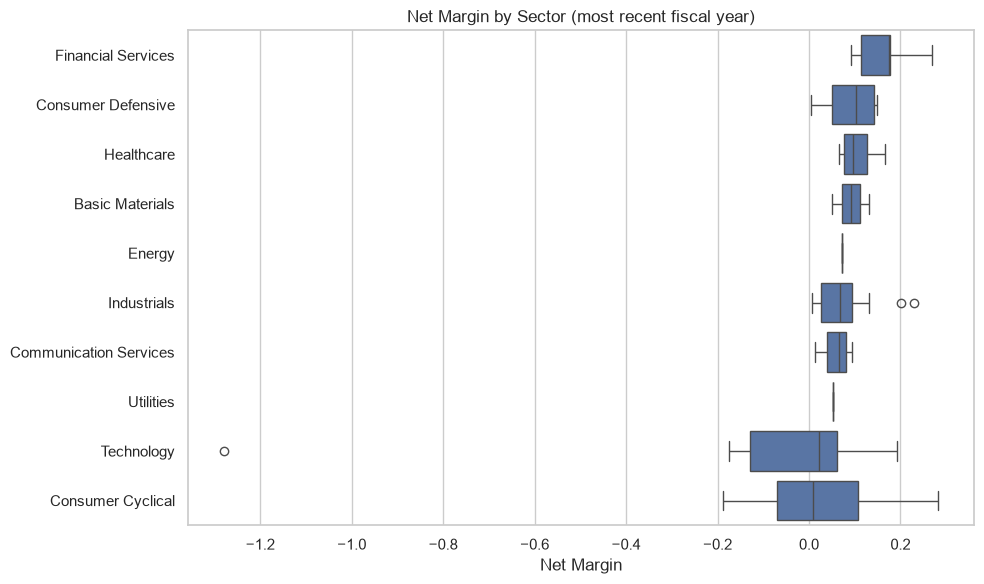

In [16]:
latest = df.sort_values("fiscal_year_end").groupby("ticker").tail(1)

plt.figure(figsize=(10, 6))
order = latest.groupby("sector")["net_margin"].median().sort_values(ascending=False).index
sns.boxplot(data=latest, x="net_margin", y="sector", order=order)
plt.title("Net Margin by Sector (most recent fiscal year)")
plt.xlabel("Net Margin")
plt.ylabel("")
plt.tight_layout()
plt.show()


### 4.2 Top / bottom companies by ROE (most recent year)

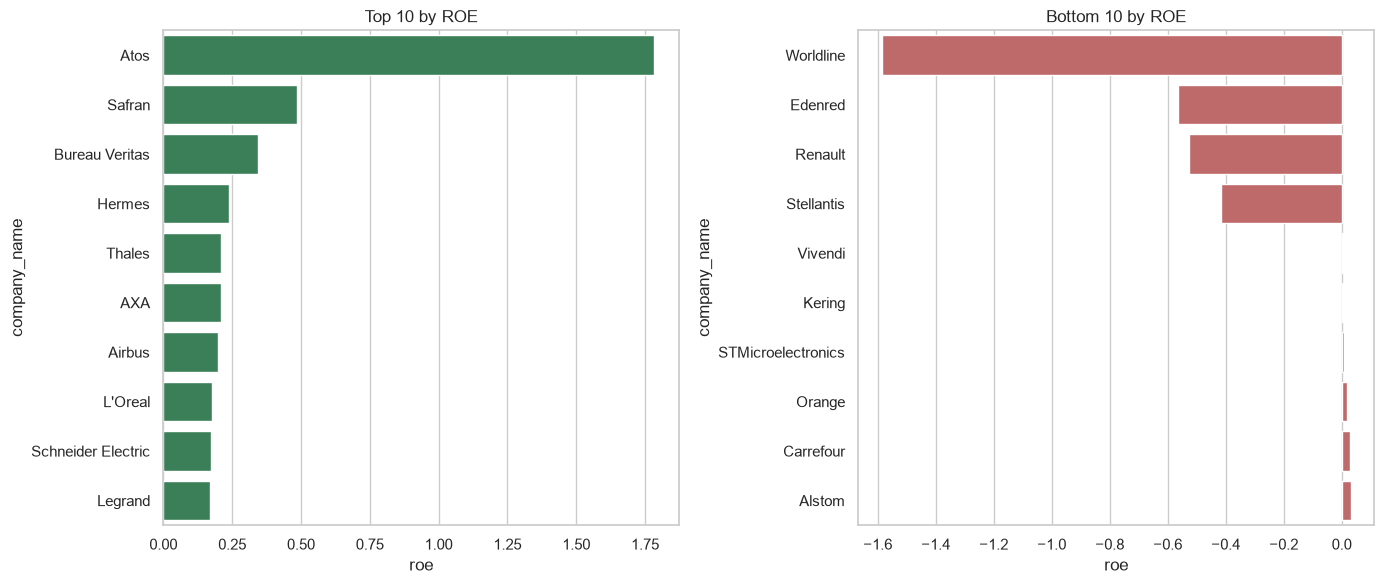

In [17]:
top_roe = latest.nlargest(10, "roe")[["company_name", "sector", "roe"]]
bottom_roe = latest.nsmallest(10, "roe")[["company_name", "sector", "roe"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.barplot(data=top_roe, x="roe", y="company_name", ax=axes[0], color="seagreen")
axes[0].set_title("Top 10 by ROE")
sns.barplot(data=bottom_roe, x="roe", y="company_name", ax=axes[1], color="indianred")
axes[1].set_title("Bottom 10 by ROE")
plt.tight_layout()
plt.show()


### 4.3 Revenue growth trend over time (median across companies, by sector)

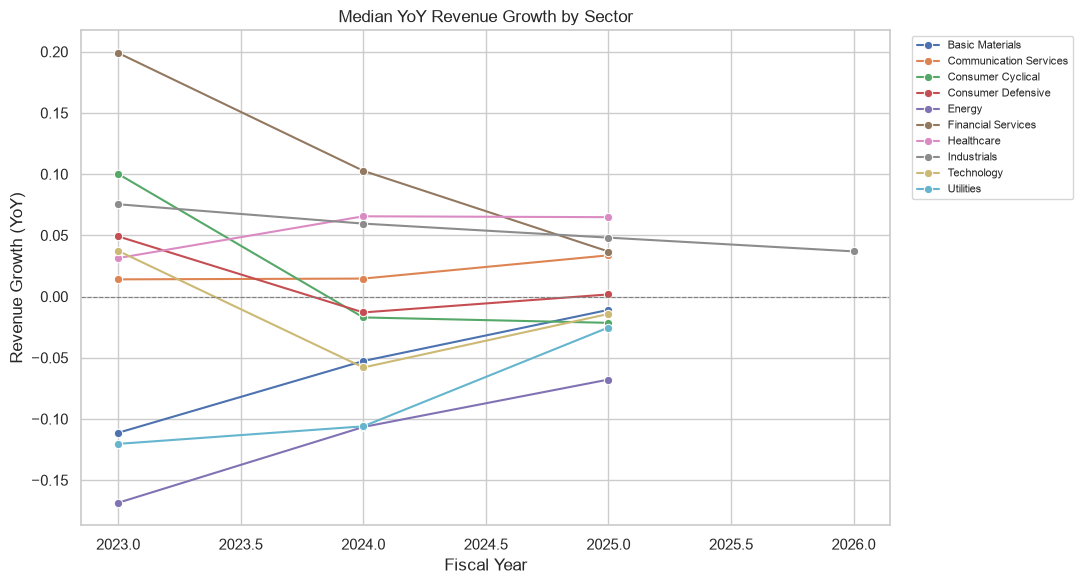

In [18]:
trend = df.dropna(subset=["revenue_growth_yoy"]).groupby(["fiscal_year", "sector"])["revenue_growth_yoy"].median().reset_index()

plt.figure(figsize=(11, 6))
sns.lineplot(data=trend, x="fiscal_year", y="revenue_growth_yoy", hue="sector", marker="o")
plt.axhline(0, color="grey", linewidth=0.8, linestyle="--")
plt.title("Median YoY Revenue Growth by Sector")
plt.ylabel("Revenue Growth (YoY)")
plt.xlabel("Fiscal Year")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


### 4.4 Profitability vs. growth: is there a relationship?

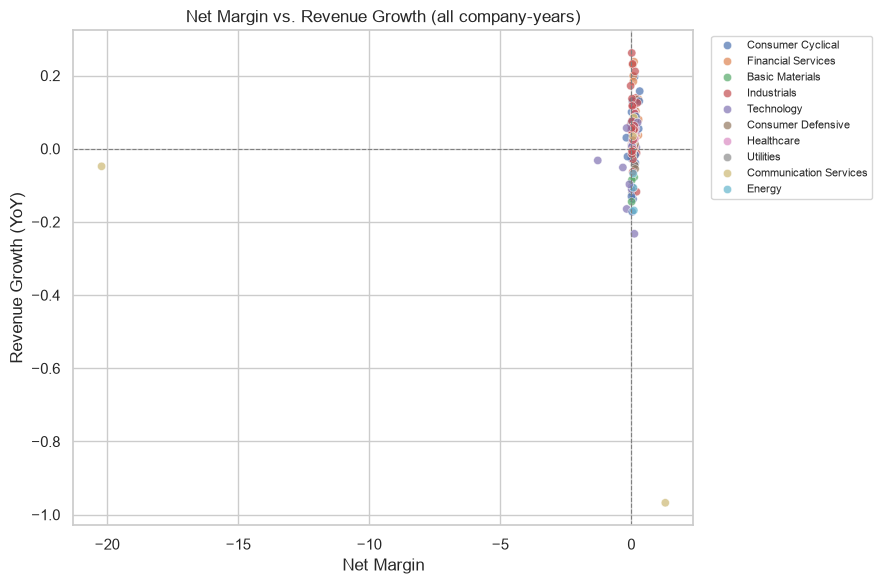

                    net_margin  operating_margin   roe   roa  debt_to_equity  \
net_margin                1.00              0.39  0.04  0.72           -0.01   
operating_margin          0.39              1.00  0.08  0.60           -0.10   
roe                       0.04              0.08  1.00  0.32           -0.98   
roa                       0.72              0.60  0.32  1.00           -0.30   
debt_to_equity           -0.01             -0.10 -0.98 -0.30            1.00   
revenue_growth_yoy        0.02              0.43  0.05  0.15           -0.05   

                    revenue_growth_yoy  
net_margin                        0.02  
operating_margin                  0.43  
roe                               0.05  
roa                               0.15  
debt_to_equity                   -0.05  
revenue_growth_yoy                1.00  


In [19]:
plt.figure(figsize=(9, 6))
sns.scatterplot(data=df, x="net_margin", y="revenue_growth_yoy", hue="sector", alpha=0.7)
plt.axhline(0, color="grey", linewidth=0.8, linestyle="--")
plt.axvline(0, color="grey", linewidth=0.8, linestyle="--")
plt.title("Net Margin vs. Revenue Growth (all company-years)")
plt.xlabel("Net Margin")
plt.ylabel("Revenue Growth (YoY)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

corr = df[["net_margin", "operating_margin", "roe", "roa", "debt_to_equity", "revenue_growth_yoy"]].corr()
print(corr.round(2))


### 4.5 Correlation heatmap of key ratios

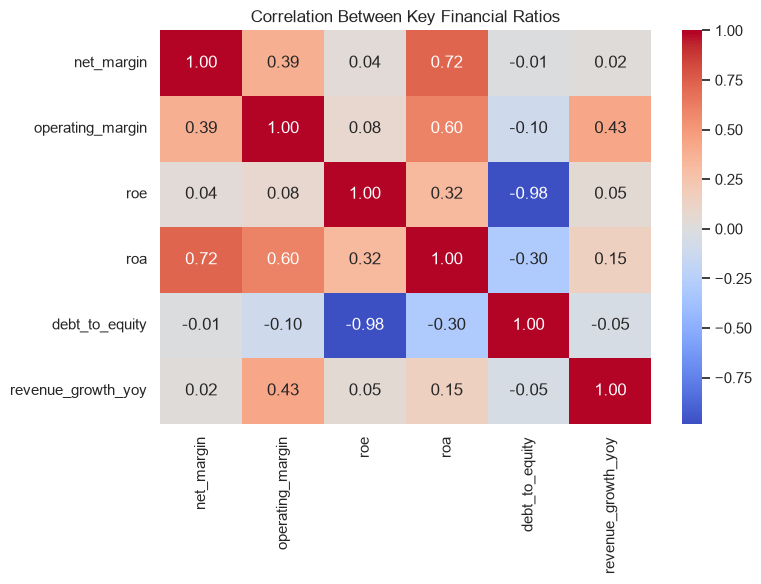

In [20]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Between Key Financial Ratios")
plt.tight_layout()
plt.show()


## 5. Key findings

**Profitability by sector**
- Financial Services shows the highest median net margin (~17.6%), followed by Consumer
  Defensive (~10.3%) and Healthcare (~9.7%). Consumer Cyclical is lowest (~1.0%),
  reflecting thin retail/auto margins versus banking/insurance economics.

**Standout ROE values**
- Atos shows an extreme ROE (~178%), almost certainly caused by stockholders' equity
  being close to zero (consistent with the company's real-world financial distress),
  which mathematically inflates the ratio rather than reflecting genuinely strong
  performance. This is a good example of why ROE should always be read alongside the
  equity base, not in isolation.
- Aside from that outlier, top ROE performers are led by Safran, Bureau Veritas, and
  Hermès (Industrials and luxury names with strong capital efficiency).

**Revenue growth**
- 36% of companies (18 of 50) show negative YoY revenue growth in their most recent
  fiscal year. This is concentrated in Technology (Atos, STMicroelectronics), Consumer
  Cyclical (Kering, LVMH, Stellantis), and Energy (TotalEnergies) — consistent with
  broader 2025-2026 headwinds in luxury demand and energy prices.
- Healthcare and Industrials show the strongest median growth among sectors.

**Leverage**
- The highest debt-to-equity ratios are concentrated in Financial Services (Crédit
  Agricole, BNP Paribas, Société Générale, 2.4x-4.0x) — expected, since leverage is
  core to the banking business model and not directly comparable to non-financial
  companies.
- On Net Debt/EBITDA, Vivendi and Getlink stand out with very high ratios (~6.7x-6.9x),
  well above the ~3x level generally considered a comfort threshold — worth flagging
  as a leverage risk signal.

**Margin, returns, and growth relationships**
- Operating margin and ROA are meaningfully correlated (0.72), suggesting operating
  efficiency does translate into asset returns.
- ROE is only weakly correlated with net margin (0.04), suggesting ROE is driven more
  by financial leverage than by underlying profitability — a useful caveat when using
  ROE alone to compare companies across sectors with very different capital structures.

**Caveats**
- Ratios were computed on annual data only (see README for why); some outlier ratios
  (e.g. Atos ROE) stem from small/near-zero denominators and should be read with the
  underlying balance sheet in mind rather than taken at face value.
